#  Learning Style: Myth or Reality?
## A Multi-Task Predictive Audit of Student Performance

In [79]:
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

### 2. Research Questions
Your project must provide an evidence-based answer to each of the following questions. The
answers must emerge from your experimental results, not from prior assumptions or literature
alone.
1. RQ1. Can a machine learning model predict a student's Exam Score and Final Grade
from their behavioural and motivational profile with meaningful accuracy, and which
model family performs best?
2. RQ2. Does the LearningStyle label add statistically meaningful predictive power once all
other features are available, as measured by an ablation experiment?
3. RQ3. Are the LearningStyle labels in the dataset independently derived, or do they
largely recapitulate structure already visible in the behavioural features — and how do
you know?
4. RQ4. If a school used your best model to intervene on at-risk students, what are the
realistic harms, who bears them, and how should the model be constrained?


### STEP 1: Data Loading, Audit, and Preprocessing

In [13]:
line = 60 * '-'
df = pd.read_csv(r'..\data\student_performance.csv')

n_rows, n_cols = df.shape

print(f"O dataset tem {n_rows} linhas e {n_cols} colunas.")
print('\n' + line + '\n')

df.info()

df.head()

O dataset tem 14003 linhas e 16 colunas.

------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [ ]:
# Listar todas as colunas
columns = df.columns.to_list()

# Separa os índices para as colunas numéricas e categóricas
numeric_indx = [0, 1, 7, 9, 11, 12]
categorical_indx = [2, 3, 4, 5, 6, 8, 10, 13, 14, 15]

# Listar as colunas numéricas e as categóricas
numeric_cols = [columns[i] for i in numeric_indx]
categorical_cols = [columns[i] for i in categorical_indx]

# Separar o dataframe em numéricas e categórics
df_categorical = df[categorical_cols]
df_numerical = df[numeric_cols]

# Exibir os dados
print(f"Colunas numéricas: \n{numeric_cols}\n")
print(f"Colunas categóricas: \n{categorical_cols[:6]}\n{categorical_cols[6:]}\n")
print("-" * 20)

print(f"\n{df_categorical.apply(pd.Series.value_counts)}")

print("-" * 20)

df_numerical.describe()

Colunas numéricas: 
['StudyHours', 'Attendance', 'Age', 'OnlineCourses', 'AssignmentCompletion', 'ExamScore']

Colunas categóricas: 
['Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'LearningStyle']
['Discussions', 'EduTech', 'StressLevel', 'FinalGrade']

--------------------

   Resources  Extracurricular  Motivation  Internet  Gender  LearningStyle  \
0     2750.0           5683.0      4112.0    1043.0  6274.0           3376   
1     7041.0           8320.0      7098.0   12960.0  7729.0           3580   
2     4212.0              NaN      2793.0       NaN     NaN           3500   
3        NaN              NaN         NaN       NaN     NaN           3547   

   Discussions  EduTech  StressLevel  FinalGrade  
0       5519.0   4074.0       2836.0        3832  
1       8484.0   9929.0       4069.0        3310  
2          NaN      NaN       7098.0        3618  
3          NaN      NaN          NaN        3243  
--------------------


,StudyHours,Attendance,Age,OnlineCourses,AssignmentCompletion,ExamScore
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,23.532172,9.891952,74.502535,70.346926
std,5.890637,11.472181,3.514293,6.112801,14.632177,17.688113
min,5.000000,60.000000,18.000000,0.000000,50.000000,40.000000
25%,16.000000,70.000000,20.000000,5.000000,62.000000,55.000000
50%,20.000000,80.000000,24.000000,10.000000,74.000000,70.000000
75%,24.000000,90.000000,27.000000,15.000000,87.000000,86.000000
max,44.000000,100.000000,29.000000,20.000000,100.000000,100.000000


**Valores Ausentes**

Como não havia valores ausentes no dataset não foi preciso criar um heatmat e nem ter uma estratégia de imputação.

In [6]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(1)
summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': pct
})

if summary['missing_count'].sum() == 0:
    print("Não há valores ausentes no dataset.")
else:
    print("Valores ausentes por coluna:")
    print(summary[summary['missing_count'] > 0])

Não há valores ausentes no dataset.


**Valores duplicados**

Consideramos que as 1.534 linhas duplicadas (10,95%) são dados coincidentes e, portanto, resolvemos não apagar.

In [78]:
duplicates = df[df.duplicated(keep=False)]
n_duplicates = df.duplicated().sum()
duplicates_per = n_duplicates/n_rows * 100

print(f"Número de linhas duplicadas: {n_duplicates} ({duplicates_per:.2f}%)")

print(duplicates.sort_values(by=list(df.columns)))

Número de linhas duplicadas: 1534 (10.95%)
      StudyHours  Attendance  Resources  Extracurricular  Motivation  \
3249           7          82          2                1           1   
3251           7          82          2                1           1   
3248           7          82          2                1           1   
3250           7          82          2                1           1   
9938           9          87          1                0           1   
...          ...         ...        ...              ...         ...   
8785          32          84          1                1           1   
8786          32          84          1                1           1   
8926          32          87          2                1           1   
8927          32          87          2                1           1   
8928          32          87          2                1           1   

      Internet  Gender  Age  LearningStyle  OnlineCourses  Discussions  \
3249         1    

**Correlação das características**

Não há correlação significativa entre nenhuma das características numéricas. Ainda assim os três pares com a maior correlação absoluta foram:
1. Attendance e Age: -0.044
2. StudyHours e Attendance: 0.028
3. AssignmentCompletion	e ExamScore: 0.025

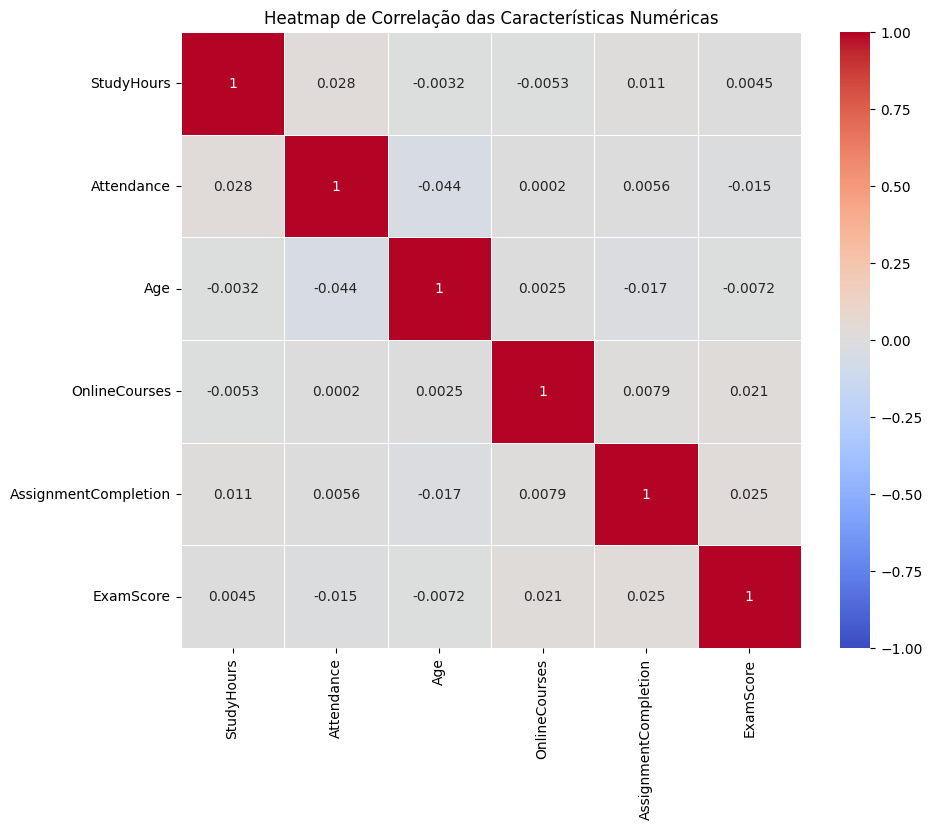

In [87]:
# Calcular a matriz de correlação
# O método .corr() calcula por padrão a correlação de Pearson
corr_matrix = df_numerical.corr()

# Criar o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,      # Mostra os valores dentro dos quadrados
            cmap='coolwarm', # Escala de cores (azul frio para negativo, vermelho quente para positivo)
            center=0,
            fmt=".2g",       # Formatação dos números
            vmin=-1, vmax=1,
            linewidths=0.5)  # Pequeno espaço entre os quadrados

plt.title('Heatmap de Correlação das Características Numéricas')
plt.show()

### Key Features

- **Study behaviors & engagement →** StudyHours, Attendance, Extracurricular, AssignmentCompletion, OnlineCourses, Discussions
- **Resources & environment →** Resources, Internet, EduTech
- **Motivation & psychology →** Motivation, StressLevel
- **Demographics →** Gender, Age (18–30 years)
- **Learning preference →** LearningStyle
- **Performance indicators →** ExamScore, FinalGrade

### Column Descriptions

- **StudyHours** – Number of study hours per week. [Numeric]
- **Attendance** – Percentage of classes attended. [Numeric]
- **Resources** – Availability level and use of academic resources (Low, Medium, High). [Categorical]
- **Extracurricular** – Participation in extracurricular activities (Y/N). [Categorical]
- **Motivation** – Self-reported motivation level (Low, Medium, High). [Categorical]
- **Internet** – Access to the internet for study purposes (Y/N). [Categorical]
- **Gender** – Student’s gender (Male, Female). [Categorical]
- **Age** – Age of student (18–30 years). [Numeric]
- **LearningStyle** – Preferred learning style (Visual, Auditory, Kinesthetic, Reading/Writing). [Categorical]
- **OnlineCourses** – Number of participations in online courses. [Numeric]
- **Discussions** – Engagement in study group discussions or forums. [Categorical]
- **AssignmentCompletion** – Rate of completing assignments on time (numeric scale). [Numeric]
- **ExamScore** – Score obtained in the main exam. [Numeric]
- **EduTech** – Usage of educational technology tools/platforms. [Categorical]
- **StressLevel** – Self-reported stress level (Low, Medium, High). [Categorical]
- **FinalGrade** – Final course grade (target variable for prediction - A, B, C, D). [Categorical]

### STEP 2: Exploratory Data Analysis

Build intuition about what actually drives performance before modelling.

C:\Users\fsabb\AppData\Local\Temp\ipykernel_6216\3918086169.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='FinalGrade', ax=axes[1], palette='magma')


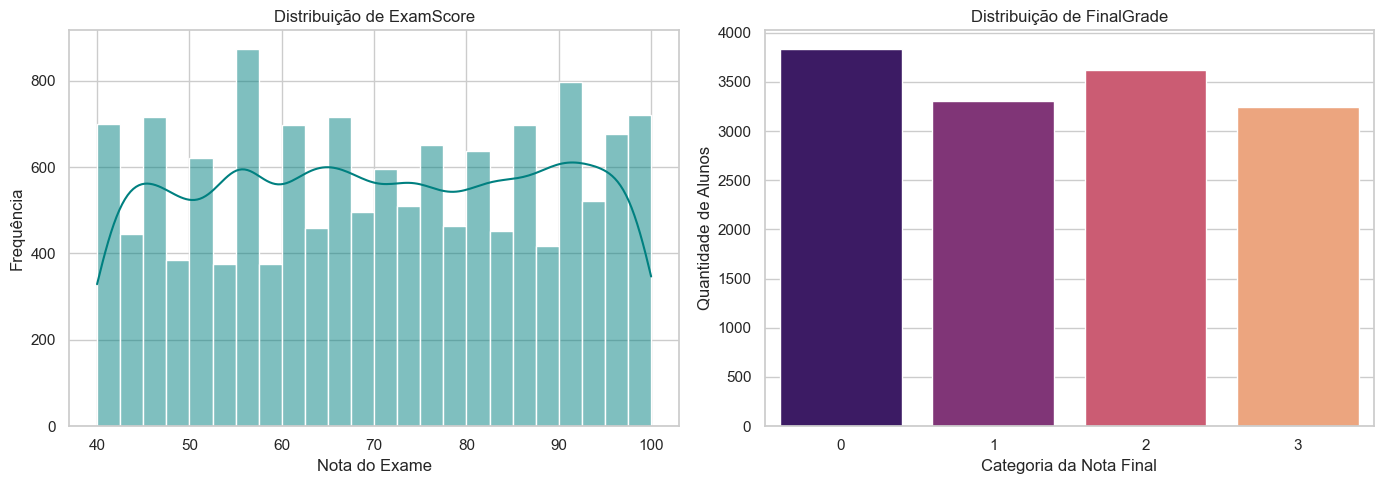

In [ ]:
# Definindo o estilo visual
sns.set_theme(style="whitegrid")

# Criando uma figura com 2 subplots (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribuição de ExamScore (Histograma + KDE)
sns.histplot(df['ExamScore'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribuição de ExamScore')
axes[0].set_xlabel('Nota do Exame')
axes[0].set_ylabel('Frequência')

# 2. Distribuição de FinalGrade (Gráfico de Contagem)
# Usamos countplot porque FinalGrade tem categorias fixas (0, 1, 2, 3)
sns.countplot(data=df, x='FinalGrade', ax=axes[1], palette='magma')
axes[1].set_title('Distribuição de FinalGrade')
axes[1].set_xlabel('Categoria da Nota Final')
axes[1].set_ylabel('Quantidade de Alunos')

# Ajusta o layout para não sobrepor os títulos
plt.tight_layout()
plt.show()

Como as duas variáveis têm naturezas diferentes, usamos um histograma com KDE (linha de densidade) para o score e um gráfico de contagem para a nota final.

1. **`ExamScore` (Histplot):** Como essa variável tem uma amplitude maior (0 a 100), o histograma agrupa os valores em "bins" (caixas) para mostrar a forma da distribuição. O parâmetro `kde=True` desenha uma linha suave que ajuda a identificar se a distribuição é Normal, Assimétrica ou se possui Picos Duplos.
2. **`FinalGrade` (Countplot):** `FinalGrade` possui apenas os valores `[0, 1, 2, 3]`, tratamos ela como uma variável categórica ordinal. O countplot é mais preciso aqui pois mostra a contagem exata de cada nível, permitindo ver rapidamente qual é a nota mais comum entre os alunos.